In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
def download_data(path):
  data = []
  for path_image in sorted(os.listdir(path=path)):
    image = Image.open(path + path_image)
    data.append(np.array(image))
  return data

X_train = download_data(r"./drive/My Drive/ISBI-2012/train/image/")
Y_train = download_data(r"./drive/My Drive/ISBI-2012/train/label/")
X_test = download_data(r"./drive/My Drive/ISBI-2012/test/image/")
Y_test = download_data(r"./drive/My Drive/ISBI-2012/test/label/")

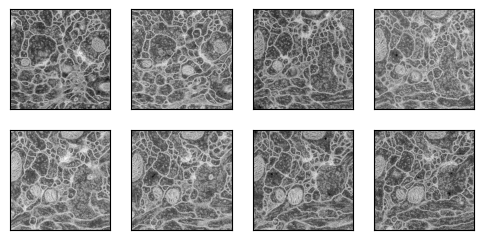

In [ ]:
plt.figure(figsize=(6,6))
for i in range(8):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i], cmap=plt.cm.binary)

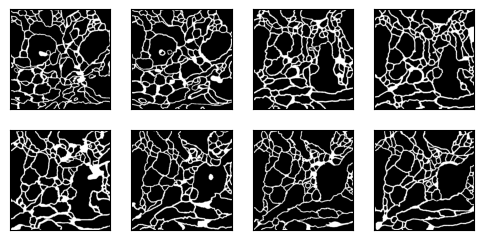

In [ ]:
plt.figure(figsize=(6,6))
for i in range(8):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(Y_train[i], cmap=plt.cm.binary)

In [ ]:
X_train_pred = np.array(X_train).reshape([30, 512, 512, 1])/255
Y_train_pred = np.array(Y_train).reshape([30, 512, 512, 1])/255

X_test_pred = np.array(X_test).reshape([30, 512, 512, 1])/255
Y_test_pred = np.array(Y_test).reshape([30, 512, 512, 1])/255

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from keras.optimizers import Adam

model = Sequential()
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(512, 512, 1)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Декодер
model.add(UpSampling2D(size=(2, 2)))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))

model.add(UpSampling2D(size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))

model.add(UpSampling2D(size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))

# Выходной слой
model.add(Conv2D(1, (1, 1), activation='sigmoid', padding='same'))

model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

In [ ]:
model.fit(X_train_pred, Y_train_pred, epochs=15, batch_size=1)

Epoch 1/15
30/30 [==============================] - 16s 125ms/step - loss: 0.6570 - accuracy: 0.7640
Epoch 2/15
30/30 [==============================] - 4s 128ms/step - loss: 0.5212 - accuracy: 0.7804
Epoch 3/15
30/30 [==============================] - 4s 127ms/step - loss: 0.5549 - accuracy: 0.7804
Epoch 4/15
30/30 [==============================] - 4s 127ms/step - loss: 0.5387 - accuracy: 0.7804
Epoch 5/15
30/30 [==============================] - 4s 127ms/step - loss: 0.4764 - accuracy: 0.7779
Epoch 6/15
30/30 [==============================] - 4s 130ms/step - loss: 0.3786 - accuracy: 0.8131
Epoch 7/15
30/30 [==============================] - 4s 129ms/step - loss: 0.3063 - accuracy: 0.8611
Epoch 8/15
30/30 [==============================] - 4s 129ms/step - loss: 0.3179 - accuracy: 0.8654
Epoch 9/15
30/30 [==============================] - 4s 135ms/step - loss: 0.2706 - accuracy: 0.8843
Epoch 10/15
30/30 [==============================] - 4s 140ms/step - loss: 0.2494 - accuracy: 0.894

In [ ]:
model.evaluate(X_test_pred, Y_test_pred, batch_size=1)

30/30 [==============================] - 2s 45ms/step - loss: 0.8862 - accuracy: 0.6135


[0.886185884475708, 0.613479733467102]

In [ ]:
out = model.predict(X_test_pred, batch_size=1)

30/30 [==============================] - 1s 44ms/step


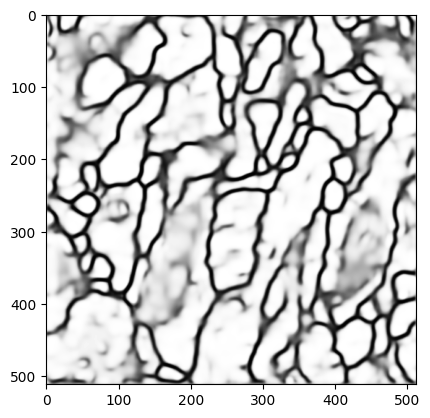

In [ ]:
I = 10 # номер картинки после обработки нейронной сетью
plt.imshow(out[I].reshape([512, 512]), cmap='gray')

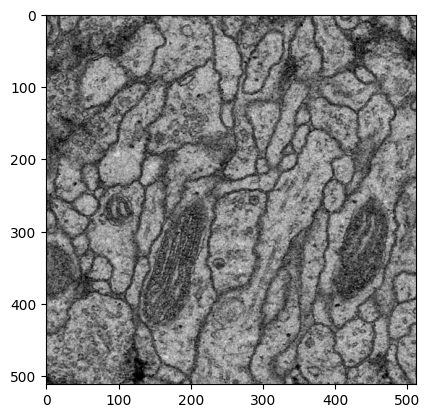

In [ ]:
plt.imshow(X_test[I].reshape([512,512]), cmap='gray')